In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Upload VAERS dataset 

In [12]:
DATA_PATH = "/Users/ariellerothman/Desktop/Capstone/COMBINED_DATA_ALL_YEARS.csv"  # change for other years / combined file
OUTPUT_DIR = "/Users/ariellerothman/Desktop/Capstone/Outputs"

df = pd.read_csv(DATA_PATH, low_memory=False)

In [13]:
# Check raw outcome column values in original data
print("Raw values from CSV (before any conversion):")
for col in ["DIED", "L_THREAT", "ER_VISIT", "HOSPITAL"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).head(10))

Raw values from CSV (before any conversion):

DIED:
DIED
NaN    2069522
Y        62909
Name: count, dtype: int64

L_THREAT:
L_THREAT
NaN    2060071
Y        72360
Name: count, dtype: int64

ER_VISIT:
ER_VISIT
NaN    2131534
Y          897
Name: count, dtype: int64

HOSPITAL:
HOSPITAL
NaN    1798694
Y       333737
Name: count, dtype: int64


In [3]:
#Get all column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132431 entries, 0 to 2132430
Data columns (total 55 columns):
 #   Column           Dtype  
---  ------           -----  
 0   VAERS_ID         int64  
 1   RECVDATE         object 
 2   STATE            object 
 3   AGE_YRS          float64
 4   CAGE_YR          float64
 5   CAGE_MO          float64
 6   SEX              object 
 7   RPT_DATE         object 
 8   SYMPTOM_TEXT     object 
 9   DIED             object 
 10  DATEDIED         object 
 11  L_THREAT         object 
 12  ER_VISIT         object 
 13  HOSPITAL         object 
 14  HOSPDAYS         float64
 15  X_STAY           object 
 16  DISABLE          object 
 17  RECOVD           object 
 18  VAX_DATE         object 
 19  ONSET_DATE       object 
 20  NUMDAYS          float64
 21  LAB_DATA         object 
 22  V_ADMINBY        object 
 23  V_FUNDBY         object 
 24  OTHER_MEDS       object 
 25  CUR_ILL          object 
 26  HISTORY          object 
 27  PRIOR_VAX   

In [4]:
#subset for COVID CASES
df_covid = df[df["VAX_TYPE"] == "COVID19"].copy()

print("Original shape:", df.shape)
print("COVID subset shape:", df_covid.shape)


Original shape: (2132431, 55)
COVID subset shape: (1702653, 55)


In [20]:

# -----------------------------
# 1) Drop columns
# -----------------------------
cols_to_drop = [
    "CAGE_YR", "CAGE_MO", "RPT_DATE", "RECOVD", "V_FUNDBY", "V_ADMINBY",
    "SPLTTYPE", "FORM_VERS", "TODAYS_DATE", "ORDER_x", "ORDER_y", "ORDER"
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# -----------------------------
# 2) Identifier dtype
# -----------------------------
if "VAERS_ID" in df.columns:
    df["VAERS_ID"] = pd.to_numeric(df["VAERS_ID"], errors="coerce").astype("Int64")  # nullable int

# -----------------------------
# 3) Dates -> datetime + features
# -----------------------------
date_cols = ["RECVDATE", "VAX_DATE", "ONSET_DATE", "DATEDIED"]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Engineer ONSET_INTERVAL (days) and YEAR/MONTH from RECVDATE (common choice)
if {"ONSET_DATE", "VAX_DATE"}.issubset(df.columns):
    df["ONSET_INTERVAL"] = (df["ONSET_DATE"] - df["VAX_DATE"]).dt.days

if "RECVDATE" in df.columns:
    df["YEAR"] = df["RECVDATE"].dt.year.astype("Int64")
    df["MONTH"] = df["RECVDATE"].dt.month.astype("Int64")

# -----------------------------
# 4) Demographics
# -----------------------------
if "AGE_YRS" in df.columns:
    df["AGE_YRS"] = pd.to_numeric(df["AGE_YRS"], errors="coerce").astype(float)

for c in ["SEX", "STATE"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

# -----------------------------
# 5) Outcomes -> 0/1 integers
# -----------------------------
def to_binary(series: pd.Series) -> pd.Series:
    """
    Map VAERS binary encodings to 0/1.
    For VAERS: Y/1 means outcome occurred, missing/N/0 means it didn't.
    Returns Int64 (no NAs - all converted to 0 or 1).
    """
    # If already numeric, convert to Int64 and fillna with 0
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce").fillna(0).astype("Int64")
    
    # For string inputs, apply mapping
    s = series.astype("string").str.strip().str.upper()
    mapping = {
        "Y": 1, "YES": 1, "TRUE": 1, "T": 1, "1": 1,
        "N": 0, "NO": 0, "FALSE": 0, "F": 0, "0": 0,
        "": 0, "NA": 0, "N/A": 0, "NONE": 0, "<NA>": 0
    }
    out = s.map(mapping)
    # Fill any remaining NaNs with 0 (unmapped values treated as "no")
    return out.fillna(0).astype("Int64")

outcome_cols = ["DIED", "L_THREAT", "ER_VISIT", "ER_ED_VISIT", "HOSPITAL", "DISABLE", "BIRTH_DEFECT", "X_STAY"]
for c in outcome_cols:
    if c in df.columns:
        df[c] = to_binary(df[c])

# Create/update SERIOUS: common definition = any serious flag is 1
serious_inputs = [c for c in outcome_cols if c in df.columns]
if serious_inputs:
    # row-wise max across flags; all are now 0/1 (no NAs)
    df["SERIOUS"] = df[serious_inputs].max(axis=1).astype("Int64")

# -----------------------------
# 6) Vaccine variables -> category
# -----------------------------
vax_cat_cols = ["VAX_TYPE", "VAX_MANU", "VAX_NAME", "VAX_DOSE_SERIES", "VAX_ROUTE", "VAX_SITE"]
for c in vax_cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")

# -----------------------------
# 7) Numeric
# -----------------------------
for c in ["HOSPDAYS", "NUMDAYS"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(float)

# -----------------------------
# 8) Text fields -> string
# -----------------------------
text_cols = ["SYMPTOM_TEXT", "LAB_DATA", "OTHER_MEDS", "CUR_ILL", "HISTORY", "PRIOR_VAX", "ALLERGIES"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].astype("string")

# -----------------------------
# 9) Quick sanity checks
# -----------------------------
print(df.dtypes)
print("\nMissingness (%), top 15:")
print((df.isna().mean() * 100).sort_values(ascending=False).head(15))


VAERS_ID                    Int64
RECVDATE           datetime64[ns]
STATE                    category
AGE_YRS                   float64
SEX                      category
SYMPTOM_TEXT       string[python]
DIED                        Int64
DATEDIED           datetime64[ns]
L_THREAT                    Int64
ER_VISIT                    Int64
HOSPITAL                    Int64
HOSPDAYS                  float64
X_STAY                      Int64
DISABLE                     Int64
VAX_DATE           datetime64[ns]
ONSET_DATE         datetime64[ns]
NUMDAYS                   float64
LAB_DATA           string[python]
OTHER_MEDS         string[python]
CUR_ILL            string[python]
HISTORY            string[python]
PRIOR_VAX          string[python]
BIRTH_DEFECT                Int64
OFC_VISIT                  object
ER_ED_VISIT                 Int64
ALLERGIES          string[python]
SYMPTOM1                   object
SYMPTOMVERSION1           float64
SYMPTOM2                   object
SYMPTOMVERSION

In [22]:
# -----------------------------
# 10) Uniqueness check
# -----------------------------
print("Unique value counts per column:")
print("="*60)
uniqueness = df.nunique().sort_values(ascending=False)
for col, n_unique in uniqueness.items():
    pct = (n_unique / len(df)) * 100
    print(f"{col:<30} {n_unique:>8,}  ({pct:>6.2f}%)")
    
print("\n" + "="*60)
print(f"Total rows: {len(df):,}")
print(f"\nColumns with >50% uniqueness (potential issues or ID-like fields):")
high_unique = uniqueness[uniqueness / len(df) > 0.5]
for col in high_unique.index:
    pct = (high_unique[col] / len(df)) * 100
    print(f"  {col:<30} {high_unique[col]:>8,}  ({pct:>6.2f}%)")

Unique value counts per column:
VAERS_ID                       1,225,247  ( 57.46%)
SYMPTOM_TEXT                   1,135,045  ( 53.23%)
OTHER_MEDS                      379,728  ( 17.81%)
HISTORY                         276,927  ( 12.99%)
LAB_DATA                        263,562  ( 12.36%)
ALLERGIES                       169,972  (  7.97%)
CUR_ILL                          96,924  (  4.55%)
VAX_LOT                          74,711  (  3.50%)
PRIOR_VAX                        50,277  (  2.36%)
SYMPTOM1                          9,736  (  0.46%)
SYMPTOM2                          9,436  (  0.44%)
SYMPTOM3                          8,890  (  0.42%)
SYMPTOM4                          8,163  (  0.38%)
SYMPTOM5                          7,688  (  0.36%)
VAX_DATE                          5,409  (  0.25%)
ONSET_DATE                        4,169  (  0.20%)
ONSET_INTERVAL                    2,892  (  0.14%)
NUMDAYS                           2,371  (  0.11%)
RECVDATE                          2,033  (  0.10

In [23]:
# Serious cases analysis
print("SERIOUS CASES ANALYSIS")
print("="*60)

serious_count = df["SERIOUS"].sum()
total_count = len(df)
serious_pct = (serious_count / total_count) * 100

print(f"Total cases:              {total_count:>12,}")
print(f"Serious cases (1):        {serious_count:>12,.0f}")
print(f"Non-serious cases (0):    {total_count - serious_count:>12,}")
print(f"\nSerious cases: {serious_pct:.2f}%")

# Breakdown by outcome type
print(f"\n\nBreakdown of serious outcomes:")
print("-"*60)
for col in ["DIED", "L_THREAT", "ER_VISIT", "ER_ED_VISIT", "HOSPITAL", "DISABLE", "BIRTH_DEFECT", "X_STAY"]:
    if col in df.columns:
        count = df[col].sum()
        pct = (count / total_count) * 100
        print(f"{col:<20} {count:>10,.0f}  ({pct:>6.2f}%)")

SERIOUS CASES ANALYSIS
Total cases:                 2,132,431
Serious cases (1):             641,934
Non-serious cases (0):       1,490,497

Serious cases: 30.10%


Breakdown of serious outcomes:
------------------------------------------------------------
DIED                     62,909  (  2.95%)
L_THREAT                 72,360  (  3.39%)
ER_VISIT                    897  (  0.04%)
ER_ED_VISIT             392,759  ( 18.42%)
HOSPITAL                333,737  ( 15.65%)
DISABLE                  82,628  (  3.87%)
BIRTH_DEFECT              1,916  (  0.09%)
X_STAY                    1,958  (  0.09%)


In [2]:
# Load and analyze the COVID case-level clean dataset
DATA_PATH_COVID_CLEAN = "/Users/ariellerothman/Desktop/Capstone/vaers_covid_case_level_clean.csv"
df_clean = pd.read_csv(DATA_PATH_COVID_CLEAN, low_memory=False)

print("Dataset loaded:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns: {df_clean.columns.tolist()}")
print(f"\nData types:\n{df_clean.dtypes}")

Dataset loaded:
Shape: (986096, 39)

Columns: ['VAERS_ID', 'DIED', 'L_THREAT', 'ER_VISIT', 'ER_ED_VISIT', 'HOSPITAL', 'DISABLE', 'BIRTH_DEFECT', 'SERIOUS', 'AGE_YRS', 'HOSPDAYS', 'NUMDAYS', 'ONSET_INTERVAL', 'RECVDATE', 'VAX_DATE', 'ONSET_DATE', 'DATEDIED', 'SEX', 'STATE', 'VAX_TYPE', 'SYMPTOM_TEXT', 'LAB_DATA', 'OTHER_MEDS', 'CUR_ILL', 'HISTORY', 'PRIOR_VAX', 'ALLERGIES', 'MAX_DOSE', 'DOSE_COUNT', 'MULTI_DOSE', 'UNKNOWN_DOSE', 'MULTI_MANUFACTURER', 'MANU__JANSSEN', 'MANU__MODERNA', 'MANU__NOVAVAX', 'MANU__PFIZER\\BIONTECH', 'MANU__UNKNOWN MANUFACTURER', 'YEAR', 'MONTH']

Data types:
VAERS_ID                        int64
DIED                            int64
L_THREAT                        int64
ER_VISIT                        int64
ER_ED_VISIT                     int64
HOSPITAL                        int64
DISABLE                         int64
BIRTH_DEFECT                    int64
SERIOUS                         int64
AGE_YRS                       float64
HOSPDAYS                     

In [27]:
# Check for class imbalance in SERIOUS column
print("\n" + "="*70)
print("CLASS IMBALANCE ANALYSIS - COVID Clean Dataset")
print("="*70)

if "SERIOUS" in df_clean.columns:
    serious_dist = df_clean["SERIOUS"].value_counts(dropna=False).sort_index()
    total = len(df_clean)
    
    print(f"\nSERIOUS column distribution:")
    print("-"*70)
    for val, count in serious_dist.items():
        pct = (count / total) * 100
        bar_length = int(pct / 2)  # Scale to 50 chars max
        bar = "█" * bar_length
        print(f"{val:>8} : {count:>10,}  ({pct:>6.2f}%)  {bar}")
    
    # Calculate imbalance ratio
    if len(serious_dist) == 2:
        class_0 = serious_dist.get(0, 0)
        class_1 = serious_dist.get(1, 0)
        if min(class_0, class_1) > 0:
            imbalance_ratio = max(class_0, class_1) / min(class_0, class_1)
            print(f"\nImbalance Ratio (majority/minority): {imbalance_ratio:.2f}:1")
            
            if imbalance_ratio > 3:
                print("⚠️  SEVERE CLASS IMBALANCE - Consider techniques like SMOTE, undersampling, or class weights")
            elif imbalance_ratio > 2:
                print("⚠️  MODERATE CLASS IMBALANCE - May need balancing techniques")
            else:
                print("✓  Relatively balanced classes")
else:
    print("SERIOUS column not found in dataset")


CLASS IMBALANCE ANALYSIS - COVID Clean Dataset

SERIOUS column distribution:
----------------------------------------------------------------------
       0 :    790,350  ( 80.15%)  ████████████████████████████████████████
       1 :    195,746  ( 19.85%)  █████████

Imbalance Ratio (majority/minority): 4.04:1
⚠️  SEVERE CLASS IMBALANCE - Consider techniques like SMOTE, undersampling, or class weights


In [4]:
# Drop unnecessary columns
cols_to_drop = ['VAX_DATE', 'ONSET_DATE', 'NUMDAYS', 'HOSPDAYS']
cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]

print(f"Dropping columns: {cols_to_drop}")
print(f"Shape before: {df_clean.shape}")

df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Shape after: {df_clean.shape}")
print(f"\nRemaining columns: {df_clean.columns.tolist()}")

Dropping columns: ['VAX_DATE', 'ONSET_DATE', 'NUMDAYS', 'HOSPDAYS']
Shape before: (986096, 39)
Shape after: (986096, 35)

Remaining columns: ['VAERS_ID', 'DIED', 'L_THREAT', 'ER_VISIT', 'ER_ED_VISIT', 'HOSPITAL', 'DISABLE', 'BIRTH_DEFECT', 'SERIOUS', 'AGE_YRS', 'ONSET_INTERVAL', 'RECVDATE', 'DATEDIED', 'SEX', 'STATE', 'VAX_TYPE', 'SYMPTOM_TEXT', 'LAB_DATA', 'OTHER_MEDS', 'CUR_ILL', 'HISTORY', 'PRIOR_VAX', 'ALLERGIES', 'MAX_DOSE', 'DOSE_COUNT', 'MULTI_DOSE', 'UNKNOWN_DOSE', 'MULTI_MANUFACTURER', 'MANU__JANSSEN', 'MANU__MODERNA', 'MANU__NOVAVAX', 'MANU__PFIZER\\BIONTECH', 'MANU__UNKNOWN MANUFACTURER', 'YEAR', 'MONTH']


In [29]:
# Analyze vaccine manufacturers
print("\n" + "="*70)
print("VACCINE MANUFACTURERS - COVID Clean Dataset")
print("="*70)

# Check for manufacturer columns (one-hot encoded)
manu_cols = [col for col in df_clean.columns if col.startswith('MANU__')]

if manu_cols:
    print(f"\nFound {len(manu_cols)} manufacturer columns (one-hot encoded):")
    print("-"*70)
    
    # Extract manufacturer names and count cases
    manu_data = []
    for col in sorted(manu_cols):
        manu_name = col.replace('MANU__', '')
        count = df_clean[col].sum()
        pct = (count / len(df_clean)) * 100
        manu_data.append((manu_name, count, pct))
    
    # Sort by count descending
    manu_data.sort(key=lambda x: x[1], reverse=True)
    
    for manu_name, count, pct in manu_data:
        print(f"  {manu_name:<35} {count:>10,.0f}  ({pct:>6.2f}%)")
    
    print(f"\nTotal manufacturers: {len(manu_cols)}")
else:
    print("\nNo one-hot encoded manufacturer columns found.")
    if 'VAX_MANU' in df_clean.columns:
        print("\nManufacturers from VAX_MANU column:")
        manu_dist = df_clean['VAX_MANU'].value_counts()
        print(manu_dist)
    else:
        print("VAX_MANU column not found either.")


VACCINE MANUFACTURERS - COVID Clean Dataset

Found 5 manufacturer columns (one-hot encoded):
----------------------------------------------------------------------
  PFIZER\BIONTECH                        459,918  ( 46.64%)
  MODERNA                                452,935  ( 45.93%)
  JANSSEN                                 73,515  (  7.46%)
  UNKNOWN MANUFACTURER                     7,615  (  0.77%)
  NOVAVAX                                    737  (  0.07%)

Total manufacturers: 5


In [30]:
# Check for impossible/unrealistic values
print("\n" + "="*70)
print("DATA QUALITY CHECK - Impossible/Unrealistic Values")
print("="*70)

issues_found = 0

# 1. AGE_YRS: Should be 0-130
if 'AGE_YRS' in df_clean.columns:
    age_issues = df_clean[(df_clean['AGE_YRS'] < 0) | (df_clean['AGE_YRS'] > 130)]
    if len(age_issues) > 0:
        print(f"\n❌ AGE_YRS Issues:")
        print(f"   Records with age < 0 or > 130: {len(age_issues):,}")
        print(f"   Min: {df_clean['AGE_YRS'].min()}, Max: {df_clean['AGE_YRS'].max()}")
        issues_found += len(age_issues)
    else:
        print(f"\n✓ AGE_YRS: All values in reasonable range (0-130)")

# 2. Binary columns: Should only be 0 or 1
binary_cols = ['DIED', 'L_THREAT', 'ER_VISIT', 'ER_ED_VISIT', 'HOSPITAL', 'DISABLE', 'BIRTH_DEFECT', 'SERIOUS', 'MULTI_DOSE', 'UNKNOWN_DOSE', 'MULTI_MANUFACTURER']
for col in binary_cols:
    if col in df_clean.columns:
        invalid_vals = df_clean[~df_clean[col].isin([0, 1])]
        if len(invalid_vals) > 0:
            print(f"\n❌ {col} Issues:")
            print(f"   Records with values not in [0,1]: {len(invalid_vals):,}")
            print(f"   Unique values: {sorted(df_clean[col].unique())}")
            issues_found += len(invalid_vals)

if all(len(df_clean[~df_clean[col].isin([0, 1])]) == 0 for col in binary_cols if col in df_clean.columns):
    print(f"\n✓ Binary columns: All values are 0 or 1")

# 3. Counts: Should be >= 0
if 'DOSE_COUNT' in df_clean.columns:
    dose_issues = df_clean[df_clean['DOSE_COUNT'] < 0]
    if len(dose_issues) > 0:
        print(f"\n❌ DOSE_COUNT Issues: {len(dose_issues):,} negative values")
        issues_found += len(dose_issues)
    else:
        print(f"\n✓ DOSE_COUNT: All values >= 0")

# 4. Dates: Check for logical inconsistencies
if all(col in df_clean.columns for col in ['VAX_DATE', 'ONSET_DATE', 'RECVDATE']):
    vax_date = pd.to_datetime(df_clean['VAX_DATE'], errors='coerce')
    onset_date = pd.to_datetime(df_clean['ONSET_DATE'], errors='coerce')
    recv_date = pd.to_datetime(df_clean['RECVDATE'], errors='coerce')
    
    # Onset should be after vaccination
    onset_before_vax = (onset_date < vax_date) & (onset_date.notna()) & (vax_date.notna())
    if onset_before_vax.sum() > 0:
        print(f"\n❌ Date Logic Issues:")
        print(f"   ONSET_DATE before VAX_DATE: {onset_before_vax.sum():,}")
        issues_found += onset_before_vax.sum()
    
    # RECVDATE should be after VAX_DATE (report comes after vaccination)
    recv_before_vax = (recv_date < vax_date) & (recv_date.notna()) & (vax_date.notna())
    if recv_before_vax.sum() > 0:
        print(f"   RECVDATE before VAX_DATE: {recv_before_vax.sum():,}")
        issues_found += recv_before_vax.sum()
    
    if onset_before_vax.sum() == 0 and recv_before_vax.sum() == 0:
        print(f"\n✓ Date logic: All temporal relationships are valid")

# 5. HOSPDAYS and NUMDAYS: Should be >= 0
for col in ['HOSPDAYS', 'NUMDAYS']:
    if col in df_clean.columns:
        neg_issues = df_clean[(df_clean[col] < 0) & (df_clean[col].notna())]
        if len(neg_issues) > 0:
            print(f"\n❌ {col} Issues: {len(neg_issues):,} negative values")
            issues_found += len(neg_issues)

if 'HOSPDAYS' in df_clean.columns and 'NUMDAYS' in df_clean.columns:
    if all(len(df_clean[(df_clean[col] < 0) & (df_clean[col].notna())]) == 0 for col in ['HOSPDAYS', 'NUMDAYS']):
        print(f"\n✓ HOSPDAYS & NUMDAYS: All values >= 0")

# 6. ONSET_INTERVAL: Should be >= 0 (onset after vaccination)
if 'ONSET_INTERVAL' in df_clean.columns:
    neg_intervals = df_clean[(df_clean['ONSET_INTERVAL'] < 0) & (df_clean['ONSET_INTERVAL'].notna())]
    if len(neg_intervals) > 0:
        print(f"\n❌ ONSET_INTERVAL Issues: {len(neg_intervals):,} negative intervals")
        issues_found += len(neg_intervals)
    else:
        print(f"\n✓ ONSET_INTERVAL: All values >= 0")

# Summary
print(f"\n" + "="*70)
if issues_found == 0:
    print("✓ NO IMPOSSIBLE VALUES FOUND - Dataset is clean!")
else:
    print(f"⚠️  TOTAL ISSUES FOUND: {issues_found:,} records with impossible values")
    print("   Consider investigating and cleaning these records before modeling")
print("="*70)


DATA QUALITY CHECK - Impossible/Unrealistic Values

✓ AGE_YRS: All values in reasonable range (0-130)

✓ Binary columns: All values are 0 or 1

✓ DOSE_COUNT: All values >= 0

❌ Date Logic Issues:
   ONSET_DATE before VAX_DATE: 20,314
   RECVDATE before VAX_DATE: 134

✓ HOSPDAYS & NUMDAYS: All values >= 0

❌ ONSET_INTERVAL Issues: 20,314 negative intervals

⚠️  TOTAL ISSUES FOUND: 40,762 records with impossible values
   Consider investigating and cleaning these records before modeling


In [31]:
# Analyze proportion of empty narratives/text fields
print("\n" + "="*70)
print("NARRATIVE TEXT ANALYSIS - COVID Clean Dataset")
print("="*70)

narrative_cols = ['SYMPTOM_TEXT', 'LAB_DATA', 'OTHER_MEDS', 'CUR_ILL', 'HISTORY', 'PRIOR_VAX', 'ALLERGIES']
total_records = len(df_clean)

print(f"\nEmpty/Missing Narrative Fields:")
print("-"*70)

empty_stats = []
for col in narrative_cols:
    if col in df_clean.columns:
        # Count null/NaN values
        null_count = df_clean[col].isna().sum()
        
        # Count empty strings or whitespace-only
        if df_clean[col].dtype == 'object':
            empty_str = df_clean[col].astype(str).str.strip().eq('').sum()
            # Add back the NaN count to avoid double counting
            empty_str = empty_str - null_count if empty_str >= null_count else 0
        else:
            empty_str = 0
        
        total_empty = null_count + empty_str
        empty_pct = (total_empty / total_records) * 100
        filled_count = total_records - total_empty
        filled_pct = (filled_count / total_records) * 100
        
        empty_stats.append((col, total_empty, empty_pct, filled_count, filled_pct))

# Sort by empty percentage descending
empty_stats.sort(key=lambda x: x[2], reverse=True)

for col, empty, empty_pct, filled, filled_pct in empty_stats:
    bar_length = int(empty_pct / 2)
    bar = "█" * bar_length
    print(f"{col:<20} Empty: {empty_pct:>6.2f}%  {bar:40} Filled: {filled_pct:>6.2f}%")

# Summary statistics
print(f"\n" + "-"*70)
print("SUMMARY:")

# Records with at least one narrative field filled
has_any_narrative = df_clean[narrative_cols].notna().any(axis=1).sum()
no_narrative = total_records - has_any_narrative
no_narrative_pct = (no_narrative / total_records) * 100

print(f"  Records with ANY narrative:     {has_any_narrative:>10,}  ({100-no_narrative_pct:>6.2f}%)")
print(f"  Records with NO narrative:      {no_narrative:>10,}  ({no_narrative_pct:>6.2f}%)")

# Records with all narrative fields filled
all_fields_filled = df_clean[narrative_cols].notna().all(axis=1).sum()
all_fields_filled_pct = (all_fields_filled / total_records) * 100
print(f"  Records with ALL narratives:    {all_fields_filled:>10,}  ({all_fields_filled_pct:>6.2f}%)")

# Average number of narrative fields per record
narrative_count_per_record = df_clean[narrative_cols].notna().sum(axis=1)
avg_narratives = narrative_count_per_record.mean()
print(f"  Avg narrative fields per record: {avg_narratives:>9.2f}")

if no_narrative_pct > 30:
    print(f"\n⚠️  WARNING: Over 30% of records have no narrative text")
    print("   This may impact model performance or require alternative features")


NARRATIVE TEXT ANALYSIS - COVID Clean Dataset

Empty/Missing Narrative Fields:
----------------------------------------------------------------------
PRIOR_VAX            Empty:  95.38%  ███████████████████████████████████████████████ Filled:   4.62%
CUR_ILL              Empty:  73.70%  ████████████████████████████████████     Filled:  26.30%
LAB_DATA             Empty:  67.79%  █████████████████████████████████        Filled:  32.21%
ALLERGIES            Empty:  63.01%  ███████████████████████████████          Filled:  36.99%
OTHER_MEDS           Empty:  53.46%  ██████████████████████████               Filled:  46.54%
HISTORY              Empty:  51.68%  █████████████████████████                Filled:  48.32%
SYMPTOM_TEXT         Empty:   0.14%                                           Filled:  99.86%

----------------------------------------------------------------------
SUMMARY:
  Records with ANY narrative:        985,167  ( 99.91%)
  Records with NO narrative:             929  (


DETAILED SYMPTOM_TEXT ANALYSIS

SYMPTOM_TEXT Length Statistics (non-empty records only):
----------------------------------------------------------------------
  Count:               984,717
  Mean:                    727 chars
  Median (50%):            313 chars
  Std Dev:                1039
  Min:                       1 chars
  Max:                   63999 chars

Percentiles:
  25th (Q1):               102 chars
  50th (Q2):               313 chars
  75th (Q3):              1052 chars
  90th:                   1838 chars
  95th:                   2499 chars
  99th:                   4596 chars

✓ Full range histogram saved to: /Users/ariellerothman/Desktop/Capstone/Outputs/symptom_text_full_range_distribution.png


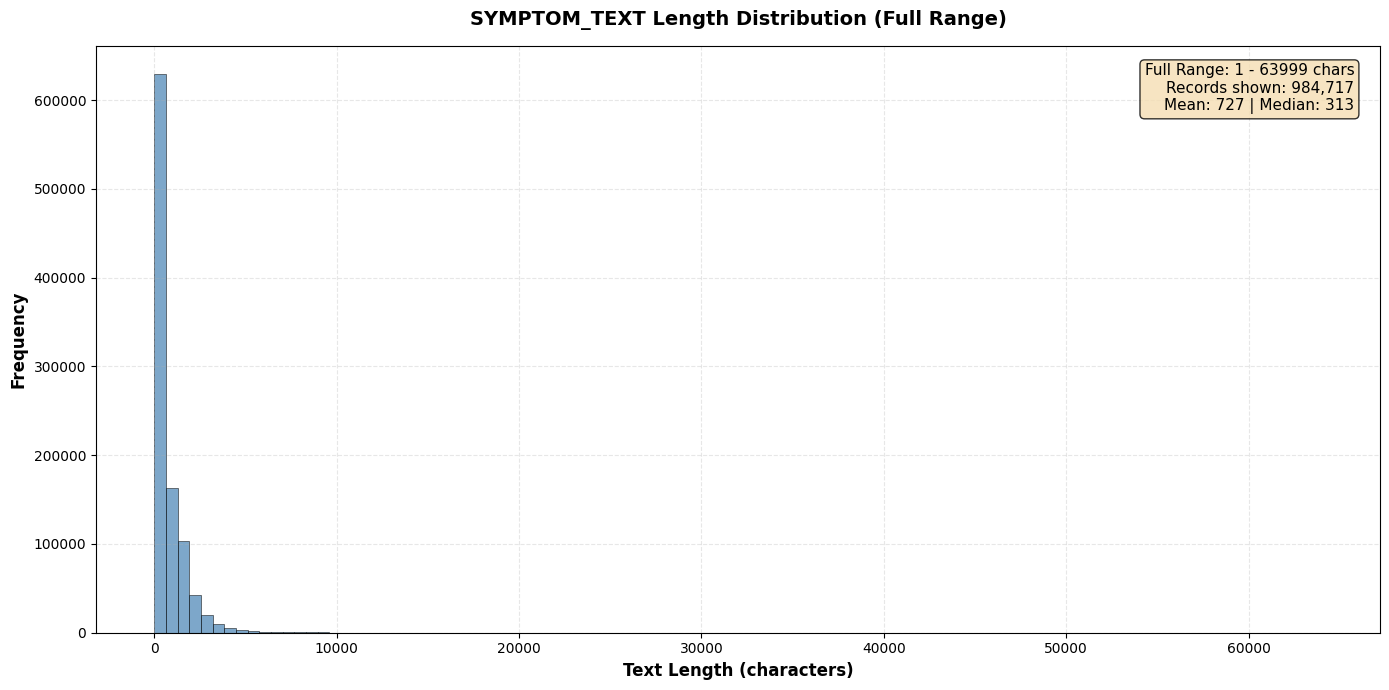


----------------------------------------------------------------------
Distribution by Length Ranges:
----------------------------------------------------------------------
  1-100 chars             243,469  ( 24.72%)  ████████████
  101-500 chars           343,655  ( 34.90%)  █████████████████
  501-1000 chars          138,168  ( 14.03%)  ███████
  1001-2000 chars         178,135  ( 18.09%)  █████████
  2001-5000 chars          73,504  (  7.46%)  ███
  5001-10000 chars          6,825  (  0.69%)  
  10000+ chars                961  (  0.10%)  


In [8]:
# Detailed analysis of SYMPTOM_TEXT distribution with full range
print("\n" + "="*70)
print("DETAILED SYMPTOM_TEXT ANALYSIS")
print("="*70)

symptom_lengths = df_clean['SYMPTOM_TEXT'].fillna('').astype(str).str.len()
non_zero_symptom = symptom_lengths[symptom_lengths > 0]

# Calculate percentiles
p25 = non_zero_symptom.quantile(0.25)
p50 = non_zero_symptom.quantile(0.50)
p75 = non_zero_symptom.quantile(0.75)
p90 = non_zero_symptom.quantile(0.90)
p95 = non_zero_symptom.quantile(0.95)
p99 = non_zero_symptom.quantile(0.99)

print(f"\nSYMPTOM_TEXT Length Statistics (non-empty records only):")
print("-"*70)
print(f"  Count:          {len(non_zero_symptom):>12,}")
print(f"  Mean:           {non_zero_symptom.mean():>12.0f} chars")
print(f"  Median (50%):   {p50:>12.0f} chars")
print(f"  Std Dev:        {non_zero_symptom.std():>12.0f}")
print(f"  Min:            {non_zero_symptom.min():>12.0f} chars")
print(f"  Max:            {non_zero_symptom.max():>12.0f} chars")
print(f"\nPercentiles:")
print(f"  25th (Q1):      {p25:>12.0f} chars")
print(f"  50th (Q2):      {p50:>12.0f} chars")
print(f"  75th (Q3):      {p75:>12.0f} chars")
print(f"  90th:           {p90:>12.0f} chars")
print(f"  95th:           {p95:>12.0f} chars")
print(f"  99th:           {p99:>12.0f} chars")

# Create single visualization: FULL RANGE (all data)
fig, ax = plt.subplots(figsize=(14, 7))

ax.hist(non_zero_symptom, bins=100, color='steelblue', edgecolor='black', alpha=0.7, linewidth=0.5)

ax.set_title('SYMPTOM_TEXT Length Distribution (Full Range)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Text Length (characters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add statistics annotation
stats_text = f'Full Range: 1 - {int(non_zero_symptom.max())} chars\nRecords shown: {len(non_zero_symptom):,}\nMean: {non_zero_symptom.mean():.0f} | Median: {non_zero_symptom.median():.0f}'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

# Create output directory if it doesn't exist
import os
output_dir = '/Users/ariellerothman/Desktop/Capstone/Outputs'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(f'{output_dir}/symptom_text_full_range_distribution.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Full range histogram saved to: {output_dir}/symptom_text_full_range_distribution.png")
plt.show()

# Breakdown by ranges
print(f"\n" + "-"*70)
print("Distribution by Length Ranges:")
print("-"*70)
ranges = [
    (0, 100, "1-100 chars"),
    (100, 500, "101-500 chars"),
    (500, 1000, "501-1000 chars"),
    (1000, 2000, "1001-2000 chars"),
    (2000, 5000, "2001-5000 chars"),
    (5000, 10000, "5001-10000 chars"),
    (10000, float('inf'), "10000+ chars"),
]

for min_val, max_val, label in ranges:
    count = ((non_zero_symptom > min_val) & (non_zero_symptom <= max_val)).sum()
    pct = (count / len(non_zero_symptom)) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:<20} {count:>10,}  ({pct:>6.2f}%)  {bar}")

# Missingness Analysis & Binary Outcome Prevalence


COMPREHENSIVE MISSINGNESS ANALYSIS

Missingness Summary (sorted by % missing):
----------------------------------------------------------------------
DATEDIED                   98.26%  █████████████████████████████████████████████████
PRIOR_VAX                  95.38%  ███████████████████████████████████████████████
HOSPDAYS                   94.59%  ███████████████████████████████████████████████
CUR_ILL                    73.70%  ████████████████████████████████████
LAB_DATA                   67.79%  █████████████████████████████████
ALLERGIES                  63.01%  ███████████████████████████████
OTHER_MEDS                 53.46%  ██████████████████████████
HISTORY                    51.68%  █████████████████████████
STATE                      16.81%  ████████
MAX_DOSE                   16.41%  ████████
NUMDAYS                    13.75%  ██████
ONSET_INTERVAL             11.80%  █████
AGE_YRS                    10.43%  █████
ONSET_DATE                  9.86%  ████
VAX_DATE       

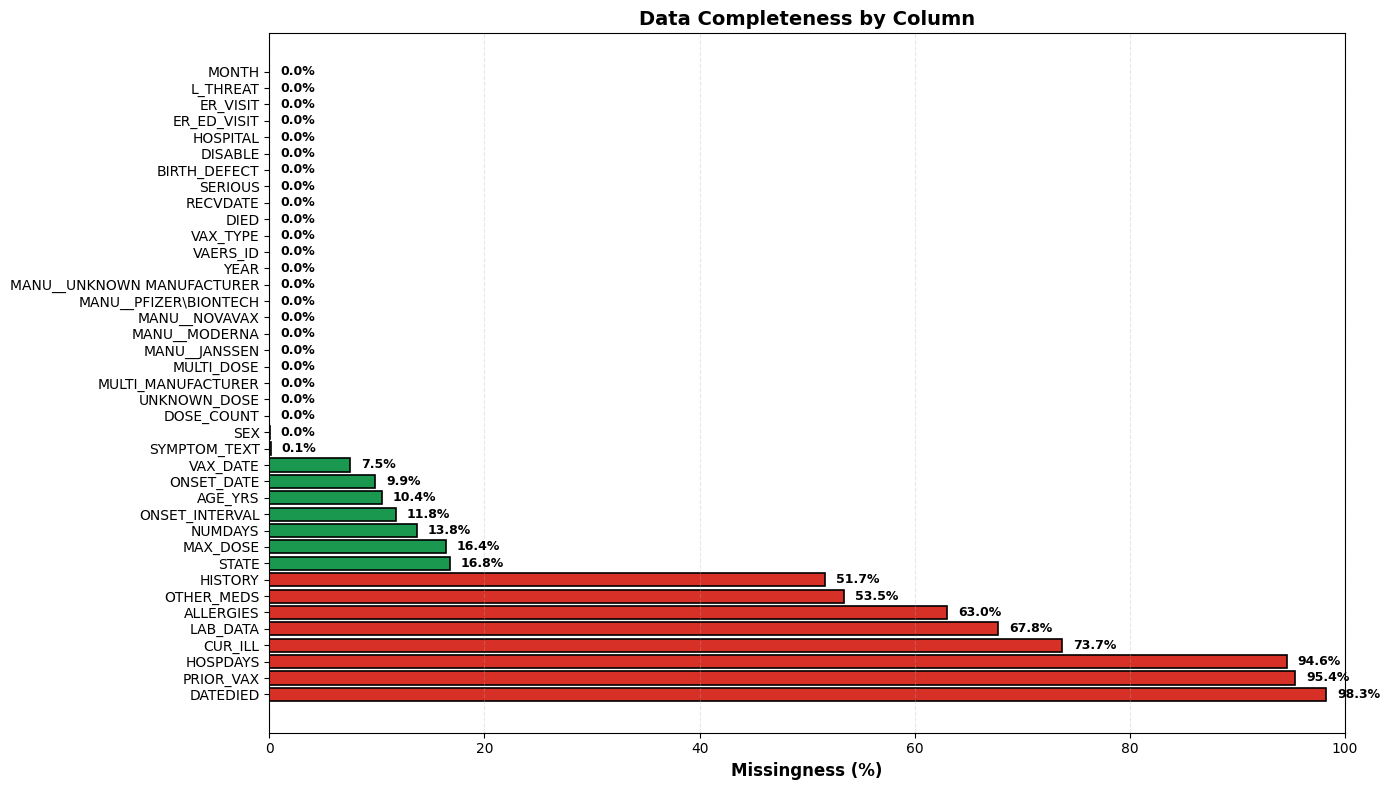


----------------------------------------------------------------------
SUMMARY STATISTICS:
  Total records: 986,096
  Total columns: 39
  Columns with 0% missing: 22
  Columns with <5% missing: 24
  Columns with 5-25% missing: 7
  Columns with >25% missing: 8

  Most complete columns: DOSE_COUNT, UNKNOWN_DOSE, MULTI_MANUFACTURER
  Most incomplete columns: DATEDIED, PRIOR_VAX, HOSPDAYS


In [5]:
# MISSINGNESS ANALYSIS FOR REPORT
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*70)
print("COMPREHENSIVE MISSINGNESS ANALYSIS")
print("="*70)

# Calculate missingness for all columns
missingness = df_clean.isna().sum()
total_rows = len(df_clean)
missingness_pct = (missingness / total_rows) * 100

# Create a summary dataframe
missing_df = pd.DataFrame({
    'Column': missingness.index,
    'Missing_Count': missingness.values,
    'Missing_Percent': missingness_pct.values,
    'Present_Count': total_rows - missingness.values,
    'Present_Percent': 100 - missingness_pct.values
}).sort_values('Missing_Percent', ascending=False)

print("\nMissingness Summary (sorted by % missing):")
print("-"*70)
for idx, row in missing_df.iterrows():
    bar = "█" * int(row['Missing_Percent'] / 2)
    print(f"{row['Column']:<25} {row['Missing_Percent']:>6.2f}%  {bar}")

# Create visualization for report - Stacked Histogram
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#d73027' if x > 50 else '#fee090' if x > 25 else '#1a9850' for x in missing_df['Missing_Percent']]
bars = ax.barh(missing_df['Column'], missing_df['Missing_Percent'], color=colors, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Missingness (%)', fontsize=12, fontweight='bold')
ax.set_title('Data Completeness by Column', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add percentage labels on bars
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row['Missing_Percent'] + 1, i, f"{row['Missing_Percent']:.1f}%", 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()

output_dir = '/Users/ariellerothman/Desktop/Capstone/Outputs'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(f'{output_dir}/missingness_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Missingness visualization saved to: {output_dir}/missingness_analysis.png")
plt.show()

# Summary statistics
print(f"\n" + "-"*70)
print("SUMMARY STATISTICS:")
print(f"  Total records: {total_rows:,}")
print(f"  Total columns: {len(df_clean.columns)}")
print(f"  Columns with 0% missing: {(missing_df['Missing_Percent'] == 0).sum()}")
print(f"  Columns with <5% missing: {(missing_df['Missing_Percent'] < 5).sum()}")
print(f"  Columns with 5-25% missing: {((missing_df['Missing_Percent'] >= 5) & (missing_df['Missing_Percent'] <= 25)).sum()}")
print(f"  Columns with >25% missing: {(missing_df['Missing_Percent'] > 25).sum()}")
print(f"\n  Most complete columns: {', '.join(missing_df[missing_df['Missing_Percent'] == 0]['Column'].head(3).tolist())}")
print(f"  Most incomplete columns: {', '.join(missing_df.head(3)['Column'].tolist())}")


BINARY OUTCOME PREVALENCE ANALYSIS

Prevalence Summary:
----------------------------------------------------------------------
     Outcome  Positive Cases  Negative Cases  Total  Prevalence (%)
        DIED           19386          966710 986096        1.965934
    L_THREAT           15974          970122 986096        1.619923
    ER_VISIT             156          985940 986096        0.015820
 ER_ED_VISIT          118965          867131 986096       12.064241
    HOSPITAL           88565          897531 986096        8.981377
     DISABLE           19523          966573 986096        1.979828
BIRTH_DEFECT             638          985458 986096        0.064700
     SERIOUS          195746          790350 986096       19.850603

✓ Prevalence table saved to: /Users/ariellerothman/Desktop/Capstone/Outputs/binary_outcome_prevalence_table.png


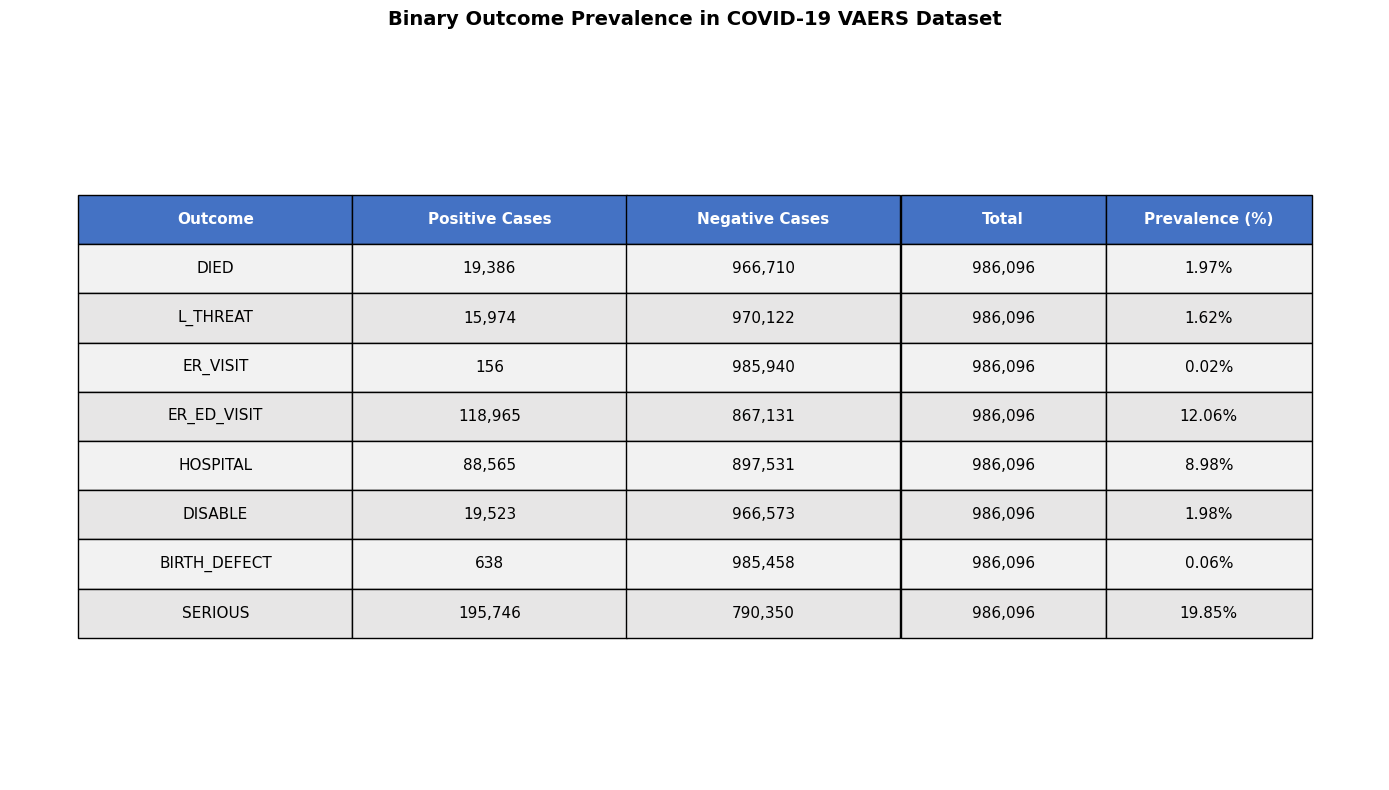


✓ Prevalence bar chart saved to: /Users/ariellerothman/Desktop/Capstone/Outputs/binary_outcome_prevalence_barchart.png


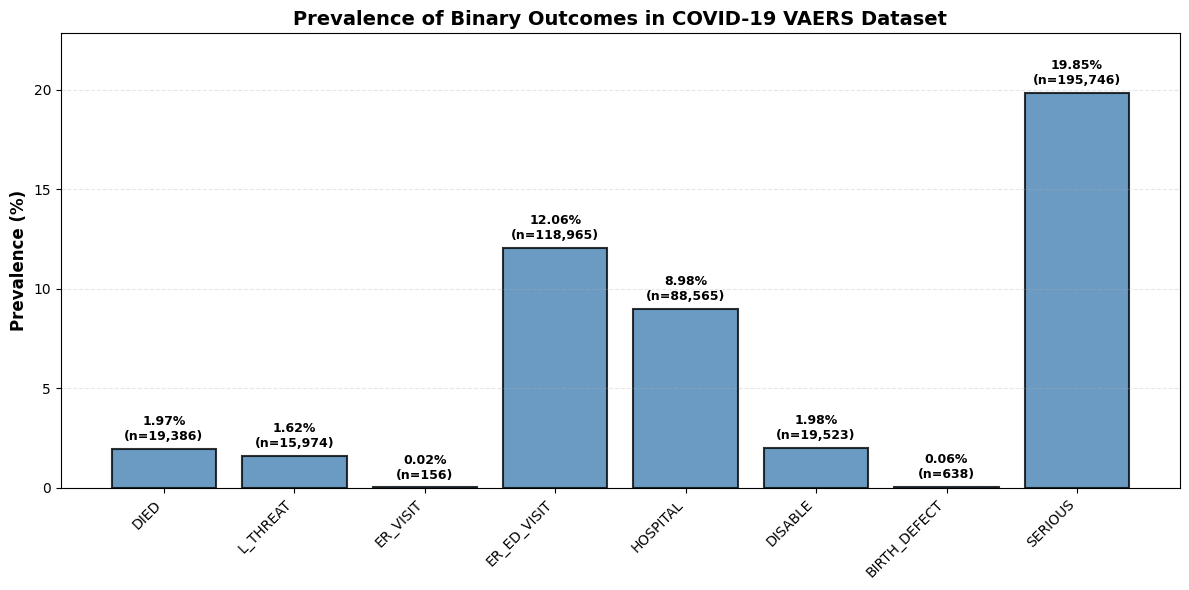


✓ Prevalence data saved to: /Users/ariellerothman/Desktop/Capstone/Outputs/binary_outcome_prevalence.csv


In [14]:
# BINARY OUTCOME PREVALENCE TABLE FOR REPORT
print("\n" + "="*70)
print("BINARY OUTCOME PREVALENCE ANALYSIS")
print("="*70)

# Define all binary outcome columns
binary_outcome_cols = ['DIED', 'L_THREAT', 'ER_VISIT', 'ER_ED_VISIT', 'HOSPITAL', 'DISABLE', 'BIRTH_DEFECT', 'X_STAY', 'SERIOUS']

# Calculate prevalence for each
prevalence_data = []
for col in binary_outcome_cols:
    if col in df_clean.columns:
        count_1 = (df_clean[col] == 1).sum()
        count_0 = (df_clean[col] == 0).sum()
        total = count_1 + count_0
        prevalence_pct = (count_1 / total) * 100
        
        prevalence_data.append({
            'Outcome': col,
            'Positive Cases': count_1,
            'Negative Cases': count_0,
            'Total': total,
            'Prevalence (%)': prevalence_pct
        })

prevalence_df = pd.DataFrame(prevalence_data)

print("\nPrevalence Summary:")
print("-"*70)
print(prevalence_df.to_string(index=False))

# Create publication-quality table visualization
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Prepare table data with formatting
table_data = []
table_data.append(['Outcome', 'Positive Cases', 'Negative Cases', 'Total', 'Prevalence (%)'])

for idx, row in prevalence_df.iterrows():
    table_data.append([
        row['Outcome'],
        f"{row['Positive Cases']:,}",
        f"{row['Negative Cases']:,}",
        f"{row['Total']:,}",
        f"{row['Prevalence (%)']:.2f}%"
    ])

# Create table
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.2, 0.2, 0.2, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data)):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#F2F2F2')

plt.title('Binary Outcome Prevalence in COVID-19 VAERS Dataset', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()

output_dir = '/Users/ariellerothman/Desktop/Capstone/Outputs'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(f'{output_dir}/binary_outcome_prevalence_table.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Prevalence table saved to: {output_dir}/binary_outcome_prevalence_table.png")
plt.show()

# Additional visualization: Bar chart of prevalence
fig, ax = plt.subplots(figsize=(12, 6))

outcomes = prevalence_df['Outcome'].tolist()
prevalences = prevalence_df['Prevalence (%)'].tolist()
positive_counts = prevalence_df['Positive Cases'].tolist()

bars = ax.bar(outcomes, prevalences, color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_ylabel('Prevalence (%)', fontsize=12, fontweight='bold')
ax.set_title('Prevalence of Binary Outcomes in COVID-19 VAERS Dataset', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(prevalences) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, prev, pos_count in zip(bars, prevalences, positive_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{prev:.2f}%\n(n={pos_count:,})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(f'{output_dir}/binary_outcome_prevalence_barchart.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Prevalence bar chart saved to: {output_dir}/binary_outcome_prevalence_barchart.png")
plt.show()

# Save as CSV for easy inclusion in reports
prevalence_df.to_csv(f'{output_dir}/binary_outcome_prevalence.csv', index=False)
print(f"\n✓ Prevalence data saved to: {output_dir}/binary_outcome_prevalence.csv")

# Automated Exploratory Data Analysis with ydata-profiling

In [40]:

# Install ydata-profiling
import subprocess
import sys

print("Installing ydata-profiling...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "ydata-profiling", "-q"])
print("✓ Installation complete!")


Installing ydata-profiling...



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✓ Installation complete!


In [7]:
# IMPUTATION: Median imputation with binary missingness indicators
# For variables with moderate missingness (approximately 11-14%)

print("\n" + "="*70)
print("IMPUTATION: Median Values + Binary Missingness Indicators")
print("="*70)

# Step 1: Identify variables with moderate missingness (11-14%)
moderate_missingness_threshold_low = 11
moderate_missingness_threshold_high = 14

# Get missing percentages from our previous analysis
missingness = df_clean.isna().sum()
missingness_pct = (missingness / len(df_clean)) * 100

# Identify columns in the moderate missingness range
moderate_cols = missing_df[
    (missing_df['Missing_Percent'] >= moderate_missingness_threshold_low) & 
    (missing_df['Missing_Percent'] <= moderate_missingness_threshold_high)
]['Column'].tolist()

# Add AGE_YRS to the imputation list (if it exists)
if 'AGE_YRS' in df_clean.columns and 'AGE_YRS' not in moderate_cols:
    moderate_cols.append('AGE_YRS')

print(f"\nVariables with {moderate_missingness_threshold_low}-{moderate_missingness_threshold_high}% missingness + AGE_YRS:")
print("-"*70)
for col in moderate_cols:
    missing_pct = missingness_pct[col]
    missing_count = missingness[col]
    marker = " ← AGE_YRS" if col == 'AGE_YRS' else ""
    print(f"  {col:<30} {missing_pct:>6.2f}%  ({missing_count:,} missing records){marker}")

# Step 2: For each variable with moderate missingness:
#         - Create binary missingness indicator
#         - Impute with median value

print(f"\n\nPerforming imputation:")
print("-"*70)

imputation_summary = []

for col in moderate_cols:
    # Check if column is numeric (required for median imputation)
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        # Step 1: Create binary missingness indicator
        missingness_col_name = f"{col}_MISSING"
        df_clean[missingness_col_name] = df_clean[col].isna().astype(int)
        
        # Step 2: Calculate median of non-missing values
        median_val = df_clean[col].median()
        
        # Step 3: Impute missing values with median
        df_clean[col] = df_clean[col].fillna(median_val)
        
        # Track summary statistics
        missing_count = df_clean[missingness_col_name].sum()
        imputation_summary.append({
            'Variable': col,
            'Missingness_Indicator': missingness_col_name,
            'Missing_Count': missing_count,
            'Missing_Percentage': (missing_count / len(df_clean)) * 100,
            'Imputed_Median': median_val
        })
        
        print(f"  ✓ {col:<30} → {missingness_col_name:<30} (median: {median_val:.2f})")
    else:
        print(f"  ⚠ {col:<30} → SKIPPED (non-numeric, cannot compute median)")

# Step 3: Create summary dataframe
imputation_df = pd.DataFrame(imputation_summary)

print(f"\n\n" + "="*70)
print("IMPUTATION SUMMARY")
print("="*70)
print(imputation_df.to_string(index=False))

# Step 4: Verify imputation
print(f"\n\nVerification - Check for remaining missing values:")
print("-"*70)
for col in moderate_cols:
    remaining_missing = df_clean[col].isna().sum()
    if remaining_missing > 0:
        print(f"  ⚠ {col}: {remaining_missing} missing values remain!")
    else:
        print(f"  ✓ {col}: No missing values (imputation successful)")

# Step 5: Show new columns created
new_missing_indicators = [f"{col}_MISSING" for col in moderate_cols]
print(f"\n\nNew binary missingness indicator columns created:")
print("-"*70)
for col in new_missing_indicators:
    if col in df_clean.columns:
        indicator_count = df_clean[col].sum()
        print(f"  {col:<30} {indicator_count:>10,.0f} cases with original missing data")

print(f"\n✓ Imputation complete!")
print(f"  Original shape: (rows, columns)")
print(f"  New shape:      {df_clean.shape}")

# Save the imputed dataset
output_dir = '/Users/ariellerothman/Desktop/Capstone/Outputs'
os.makedirs(output_dir, exist_ok=True)

imputed_data_path = f'{output_dir}/df_clean_imputed.csv'
df_clean.to_csv(imputed_data_path, index=False)
print(f"\n✓ Imputed dataset saved to: {imputed_data_path}")

# Save imputation summary
imputation_summary_path = f'{output_dir}/imputation_summary.csv'
imputation_df.to_csv(imputation_summary_path, index=False)
print(f"✓ Imputation summary saved to: {imputation_summary_path}")


IMPUTATION: Median Values + Binary Missingness Indicators

Variables with 11-14% missingness + AGE_YRS:
----------------------------------------------------------------------
  NUMDAYS                          0.00%  (0 missing records)
  ONSET_INTERVAL                   0.00%  (0 missing records)
  AGE_YRS                         10.43%  (102,852 missing records) ← AGE_YRS


Performing imputation:
----------------------------------------------------------------------
  ✓ NUMDAYS                        → NUMDAYS_MISSING                (median: 1.00)
  ✓ ONSET_INTERVAL                 → ONSET_INTERVAL_MISSING         (median: 1.00)
  ✓ AGE_YRS                        → AGE_YRS_MISSING                (median: 51.00)


IMPUTATION SUMMARY
      Variable  Missingness_Indicator  Missing_Count  Missing_Percentage  Imputed_Median
       NUMDAYS        NUMDAYS_MISSING              0            0.000000             1.0
ONSET_INTERVAL ONSET_INTERVAL_MISSING              0            0.000000     

In [25]:
### Creating comorbiditiy

# ============================================================
# RULE-BASED COMORBIDITY INDICATORS (UPDATED + NEW CATEGORIES)
# - Adds endocrine/thyroid + musculoskeletal + mental health +
#   GI + neuro_headache (migraine) + lymphatic/edema (optional)
# - Treats "none/no/unknown/NKA/NKDA" etc. as missing text
# - Saves outputs to CSV by default (no pyarrow needed)
#   (Parquet is optional if pyarrow/fastparquet is installed)
# ============================================================

import os
import re
import numpy as np
import pandas as pd

OUTDIR = "/Users/ariellerothman/Desktop/Capstone/Outputs"
os.makedirs(OUTDIR, exist_ok=True)

# Update this to your dataframe name if needed:
# df_clean = <your cleaned case-level dataframe>

FREE_TEXT_FIELDS = ["HISTORY", "CUR_ILL", "ALLERGIES", "PRIOR_VAX", "LAB_DATA", "OTHER_MEDS"]

# Terms that should be treated as "no information" (so they become missing)
NULL_TOKENS = {
    "none", "no", "n", "na", "n/a", "unknown", "unk", "none known", "not known",
    "nka", "nkda", "no known allergies", "no known drug allergies",
    "denies", "denies allergies", "no allergies", "nil", "negative"
}

_keep = re.compile(r"[^a-z0-9\s\-\/]")
_ws = re.compile(r"\s+")

def normalize_text(x) -> str:
    """Normalize free-text: lowercase, remove urls/emails/specials, collapse whitespace,
    and convert null-like tokens to empty string."""
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    if not x:
        return ""

    # Common "null-like" entries
    if x in NULL_TOKENS:
        return ""

    # remove urls/emails
    x = re.sub(r"http\S+|www\S+|https\S+", " ", x)
    x = re.sub(r"\S+@\S+", " ", x)

    # keep alnum + spaces + hyphen + slash
    x = _keep.sub(" ", x)
    x = _ws.sub(" ", x).strip()

    # If after normalization it's basically a null token, drop it
    if x in NULL_TOKENS:
        return ""

    return x

# ---------- UPDATED CATEGORY MAP ----------
# Notes:
# - Add categories where your "other" bucket showed lots of valid clinical signal:
#   hypothyroidism/thyroid, arthritis/OA, migraine, depression/anxiety, GERD, edema/lymphedema.
# - Keep patterns conservative using word boundaries (\b) to reduce false positives.
CATEGORY_MAP = {
    "CUR_ILL": {
        "acute_infection": [
            r"\bcovid\b", r"\bsars[-\s]?cov[-\s]?2\b", r"\binfluenza\b", r"\bflu\b",
            r"\binfection\b", r"\bpneumonia\b", r"\bbronchitis\b", r"\bviral\b", r"\bbacterial\b"
        ],
        "chronic_cardiovascular": [
            r"\bhypertension\b", r"\bhtn\b", r"\bcad\b", r"\bcoronary\b", r"\bafib\b",
            r"\bheart failure\b", r"\bchf\b", r"\barrhythmia\b", r"\bmi\b", r"\bmyocardial infarction\b"
        ],
        "chronic_respiratory": [
            r"\basthma\b", r"\bcopd\b", r"\bemphysema\b", r"\bchronic obstructive\b",
            r"\bsleep apnea\b", r"\bosa\b"
        ],
        "metabolic_endocrine": [
            r"\bdiabetes\b", r"\bdm\b", r"\bdm2\b", r"\btype\s?2\b", r"\bobesity\b",
            r"\bhyperlipid\w*\b", r"\bdyslipid\w*\b"
        ],
        # NEW: thyroid/endocrine explicitly (often shows up in your OTHER examples)
        "endocrine_thyroid": [
            r"\bthyroid\b", r"\bhypothyroid\w*\b", r"\bhyperthyroid\w*\b",
            r"\bhashimoto\w*\b", r"\bgraves\b"
        ],
        "autoimmune_inflammatory": [
            r"\bautoimmune\b", r"\blupus\b", r"\bsle\b", r"\bra\b", r"\brheumatoid arthritis\b",
            r"\bmultiple sclerosis\b", r"\bms\b", r"\bibs\b", r"\bibd\b", r"\bceliac\b"
        ],
        "neurologic": [
            r"\bseizure\b", r"\bepilepsy\b", r"\bstroke\b", r"\btia\b", r"\bparkinson\w*\b",
            r"\bneuropath\w*\b", r"\bdementia\b", r"\balzheimer\w*\b"
        ],
        # NEW: migraine/headache bucket (showed up in your examples)
        "neuro_headache": [
            r"\bmigraine\w*\b", r"\bheadache\w*\b", r"\bcluster headache\b"
        ],
        "cancer_immunocompromised": [
            r"\bcancer\b", r"\bmalignan\w*\b", r"\bchemotherap\w*\b", r"\bradiation\b",
            r"\btransplant\b", r"\bhiv\b", r"\baids\b",
            r"\bimmunosupp\w*\b", r"\bimmunocompromis\w*\b"
        ],
        # NEW (optional): edema/lymphedema bucket (shows in your examples)
        "lymphatic_edema": [
            r"\blymph(edema|oedema)\b", r"\bedema\b", r"\bswelling\b"
        ],
    },

    "HISTORY": {
        "cardiovascular": [
            r"\bhtn\b", r"\bhypertension\b", r"\bcad\b", r"\bcoronary\b", r"\bafib\b",
            r"\bheart failure\b", r"\bchf\b", r"\bmi\b", r"\bmyocardial infarction\b",
            r"\bvalve\b", r"\baortic stenosis\b"
        ],
        "respiratory": [
            r"\basthma\b", r"\bcopd\b", r"\bemphysema\b", r"\bchronic obstructive\b",
            r"\bosa\b", r"\bsleep apnea\b"
        ],
        "metabolic": [
            r"\bdiabetes\b", r"\bdm\b", r"\bdm2\b", r"\bobesity\b",
            r"\bhyperlipid\w*\b", r"\bdyslipid\w*\b"
        ],
        # NEW: thyroid/endocrine (common in HISTORY OTHER)
        "endocrine_thyroid": [
            r"\bthyroid\b", r"\bhypothyroid\w*\b", r"\bhyperthyroid\w*\b",
            r"\bhashimoto\w*\b", r"\bgraves\b"
        ],
        # NEW: musculoskeletal (arthritis/OA showed in your OTHER samples)
        "musculoskeletal": [
            r"\barthritis\b", r"\boveruse\b", r"\bosteoarthritis\b", r"\boa\b",
            r"\bgout\b", r"\bfibromyalgia\b", r"\bchronic pain\b"
        ],
        # NEW: mental health (often appears in HISTORY strings)
        "mental_health": [
            r"\bdepress\w*\b", r"\banxiety\b", r"\bptsd\b", r"\bbipolar\b",
            r"\bschizo\w*\b"
        ],
        # NEW: GI (GERD appears a lot)
        "gastrointestinal": [
            r"\bgerd\b", r"\bacid reflux\b", r"\bgastroesophageal\b",
            r"\bibs\b", r"\bconstipat\w*\b", r"\bdiverticul\w*\b"
        ],
        "kidney": [
            r"\bckd\b", r"\bchronic kidney\b", r"\brenal\b", r"\bdialysis\b",
            r"\brenal failure\b", r"\bkidney transplant\b", r"\btransplant\b"
        ],
        "clotting": [
            r"\bdvt\b", r"\bpe\b", r"\bthromb\w*\b", r"\bclot\b",
            r"\bembol\w*\b", r"\bantiphospholipid\b"
        ],
        "autoimmune": [
            r"\bautoimmune\b", r"\blupus\b", r"\bsle\b", r"\bra\b",
            r"\bms\b", r"\bmultiple sclerosis\b"
        ],
        "cancer_immunocompromised": [
            r"\bcancer\b", r"\bmalignan\w*\b", r"\bchemotherap\w*\b", r"\bradiation\b",
            r"\btransplant\b", r"\bhiv\b", r"\baids\b", r"\bimmunosupp\w*\b"
        ],
        "neurologic": [
            r"\bstroke\b", r"\btia\b", r"\bseizure\b", r"\bepilepsy\b",
            r"\bmigraine\w*\b", r"\bneuropath\w*\b", r"\bparkinson\w*\b"
        ],
        # NEW (optional): lymphatic/edema
        "lymphatic_edema": [
            r"\blymph(edema|oedema)\b", r"\bedema\b"
        ],
    },

    "ALLERGIES": {
        "drug_allergy": [
            r"\bpenicillin\b", r"\bsulfa\b", r"\bnsaid\b", r"\baspirin\b",
            r"\bcephalosporin\b", r"\bceclor\b", r"\bkeflex\b", r"\bdoxycycline\b"
        ],
        "food_allergy": [
            r"\bpeanut\b", r"\bnut\b", r"\begg\b", r"\bmilk\b", r"\bshellfish\b", r"\bgarlic\b"
        ],
        "latex_other_contact": [
            r"\blatex\b", r"\bdetergent\b", r"\bfragrance\b"
        ],
        "anaphylaxis_history": [
            r"\banaphylax\w*\b", r"\bepi[-\s]?pen\b", r"\bepinephrine\b"
        ],
    },

    "PRIOR_VAX": {
        "prior_covid_vax": [r"\bcovid\b", r"\bpfizer\b", r"\bmoderna\b", r"\bjanssen\b", r"\bnovavax\b"],
        "prior_flu_vax": [r"\bflu\b", r"\binfluenza\b"],
        # broaden common vaccines
        "prior_other_vax": [
            r"\bshingrix\b", r"\bshingles\b", r"\btetanus\b", r"\brabies\b",
            r"\bh1n1\b", r"\bmmr\b", r"\bhepatitis\b", r"\bvaricella\b"
        ],
        "prior_vax_reaction": [r"\breaction\b", r"\ballergic\b", r"\banaphylax\w*\b", r"\bside effect\b", r"\bsyncope\b"],
    },

    "LAB_DATA": {
        "cardiac_markers": [r"\btroponin\b", r"\bbnp\b", r"\bck[-\s]?mb\b"],
        "coagulation": [r"\bd[-\s]?dimer\b", r"\binr\b", r"\bptt\b", r"\bfibrinogen\b"],
        "inflammation": [r"\bcrp\b", r"\besr\b", r"\bferritin\b"],
        "cbc": [r"\bwbc\b", r"\bplatelet\w*\b", r"\bhemoglobin\b", r"\bhgb\b"],
        # optional: vitals/procedures bucket if you want to reduce LAB_DATA__other size
        "vitals_procedures": [r"\bbp\b", r"\bhr\b", r"\bspo2\b", r"\bultrasound\b", r"\bct\b", r"\bmri\b", r"\bx[-\s]?ray\b"],
    },

    "OTHER_MEDS": {
        "anticoagulant": [
            r"\bwarfarin\b", r"\bheparin\b", r"\beliquis\b", r"\bxarelto\b",
            r"\bapixaban\b", r"\brivaroxaban\b"
        ],
        "statin": [r"\bstatin\b", r"\batorvastatin\b", r"\bsimvastatin\b", r"\brosuvastatin\b"],
        "immunosuppressant": [r"\bprednisone\b", r"\bsteroid\b", r"\bmethotrexate\b", r"\btacrolimus\b", r"\bcyclosporine\b"],
        "diabetes_meds": [r"\binsulin\b", r"\bmetformin\b", r"\bsemaglutide\b", r"\bozempic\b", r"\bglp[-\s]?1\b"],
        # NEW: thyroid meds commonly present in meds lists
        "thyroid_meds": [r"\blevothyroxine\b", r"\bsynthroid\b", r"\bliothyronine\b"],
        # NEW: antidepressants/anxiolytics common in VAERS meds lists
        "psych_meds": [r"\bsertraline\b", r"\bfluoxetine\b", r"\bcitalopram\b", r"\bescitalopram\b", r"\bbuspirone\b", r"\balprazolam\b"],
    },
}

def compile_map(category_map):
    compiled = {}
    for col, cats in category_map.items():
        compiled[col] = {cat: [re.compile(p) for p in pats] for cat, pats in cats.items()}
    return compiled

COMPILED_MAP = compile_map(CATEGORY_MAP)

def flag_any(text: str, patterns) -> int:
    if not text:
        return 0
    return int(any(p.search(text) for p in patterns))

# ----------------------------
# APPLY TO df_clean
# ----------------------------
df_clean = df_clean.copy()

for col in FREE_TEXT_FIELDS:
    if col not in df_clean.columns:
        continue

    norm_col = f"{col}_NORM"
    df_clean[norm_col] = df_clean[col].apply(normalize_text)

    # missingness indicator after null-token normalization
    df_clean[f"{col}_MISSING"] = (df_clean[norm_col].str.len() == 0).astype("int8")

    # dictionary flags
    if col in COMPILED_MAP:
        cat_cols = []
        for cat, pats in COMPILED_MAP[col].items():
            outcol = f"{col}__{cat}"
            df_clean[outcol] = df_clean[norm_col].apply(lambda t: flag_any(t, pats)).astype("int8")
            cat_cols.append(outcol)

        # "other" = has text but did not match any category
        df_clean[f"{col}__other"] = (
            (df_clean[f"{col}_MISSING"] == 0) & (df_clean[cat_cols].sum(axis=1) == 0)
        ).astype("int8")

# ----------------------------
# SAVE ENGINEERED FEATURES
# ----------------------------
engineered_cols = [c for c in df_clean.columns if "__" in c or c.endswith("_MISSING")]

comorb_df = df_clean[["VAERS_ID"] + engineered_cols].copy()

# 1) Always save CSV (no extra deps)
csv_path = os.path.join(OUTDIR, "comorbidity_indicators.csv")
comorb_df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path, "shape:", comorb_df.shape)

# 2) Optional Parquet (only if engine installed)
parquet_path = os.path.join(OUTDIR, "comorbidity_indicators.parquet")
try:
    comorb_df.to_parquet(parquet_path, index=False)
    print("Saved Parquet:", parquet_path)
except Exception as e:
    print("Parquet not saved (missing engine). CSV is saved and sufficient.")
    print("Parquet error:", repr(e))

# ----------------------------
# QUICK DIAGNOSTICS
# ----------------------------
print("\nIndicator count:", len(engineered_cols))
top_counts = comorb_df[engineered_cols].sum().sort_values(ascending=False).head(30)
diag_df = pd.DataFrame({"count": top_counts, "percent": (top_counts / len(comorb_df) * 100).round(3)})
print("\nTop indicators by prevalence:")
print(diag_df)

# Optional: show "OTHER" examples for each field to see what you're missing
def show_other_examples(field, n=10):
    other_col = f"{field}__other"
    if other_col not in df_clean.columns:
        return
    mask = (df_clean[other_col] == 1) & (df_clean[field].notna())
    print(f"\n{field} OTHER examples (n={n}):")
    print(df_clean.loc[mask, field].head(n))

for fld in ["HISTORY", "CUR_ILL", "ALLERGIES", "PRIOR_VAX", "LAB_DATA", "OTHER_MEDS"]:
    if fld in df_clean.columns:
        show_other_examples(fld, n=10)

Saved CSV: /Users/ariellerothman/Desktop/Capstone/Outputs/comorbidity_indicators.csv shape: (986096, 60)
Parquet not saved (missing engine). CSV is saved and sufficient.
Parquet error: ImportError("Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.\nA suitable version of pyarrow or fastparquet is required for parquet support.\nTrying to import the above resulted in these errors:\n - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.\n - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.")

Indicator count: 59

Top indicators by prevalence:
                                    count  percent
PRIOR_VAX_MISSING                  940654   95.392
CUR_ILL_MISSING                    862779   87.494
ALLERGIES_MISSING                  743721   75.421
LAB_DATA_MISSING                   726769   73.702
OTHER_MEDS_MISSING                 

In [26]:
from collections import defaultdict

categories = defaultdict(list)

for col in df_clean.columns:
    if "__" in col:
        field, category = col.split("__")
        categories[field].append(category)

for field, cats in categories.items():
    print(f"\n{field}")
    print("-" * len(field))
    for c in sorted(cats):
        print(c)


MANU
----
JANSSEN
MODERNA
NOVAVAX
PFIZER\BIONTECH
UNKNOWN MANUFACTURER

HISTORY
-------
autoimmune
cancer_immunocompromised
cardiovascular
clotting
endocrine_thyroid
gastrointestinal
kidney
lymphatic_edema
mental_health
metabolic
musculoskeletal
neurologic
other
respiratory

CUR_ILL
-------
acute_infection
autoimmune_inflammatory
cancer_immunocompromised
chronic_cardiovascular
chronic_respiratory
endocrine_thyroid
lymphatic_edema
metabolic_endocrine
neuro_headache
neurologic
other

ALLERGIES
---------
anaphylaxis_history
drug_allergy
food_allergy
latex_other_contact
other

PRIOR_VAX
---------
other
prior_covid_vax
prior_flu_vax
prior_other_vax
prior_vax_reaction

LAB_DATA
--------
cardiac_markers
cbc
coagulation
inflammation
other
vitals_procedures

OTHER_MEDS
----------
anticoagulant
diabetes_meds
immunosuppressant
other
psych_meds
statin
thyroid_meds


In [ ]:
df_clean.loc[df_clean["HISTORY__kidney"] == 1,
             ["HISTORY"]].sample(20)

,HISTORY
76949,"Renal disease, GERD, congestive heart failure,..."
295575,"HTN, Idiopathic thrombocytopenic purpura, SLE,..."
193166,Patient Active Problem List Diagnosis ? CAD (c...
977700,"HTN, CKD, Chronic Diastolic CHF"
646053,PAST MEDICAL HISTORY No Known Allergies Pas...
738152,"CKD, COPD, Hypertension, Kidney transplant, hy..."
796039,peripheral neuropathy TIA CAD dysrhythmia HTN ...
973370,"anxiety, arthritis, CAD, diverticulitis, DM, h..."
344357,"HTN w/ CKD, Prediabets, aortic atherosclerosis"
180659,"afib, mild chronic kidney desease, HBP"


In [20]:
indicator_cols = [c for c in df_clean.columns if "__" in c]

summary = (
    df_clean[indicator_cols]
    .sum()
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

summary["percent"] = summary["count"] / len(df_clean) * 100
summary

,count,percent
MANU__PFIZER\BIONTECH,459918,46.640287
MANU__MODERNA,452935,45.932140
OTHER_MEDS__other,384903,39.033015
HISTORY__other,317280,32.175366
LAB_DATA__other,300440,30.467622
ALLERGIES__other,280613,28.456966
CUR_ILL__other,212475,21.547091
MANU__JANSSEN,73515,7.455156
ALLERGIES__drug_allergy,72472,7.349386
HISTORY__respiratory,59525,6.036431


In [21]:
fields = ["HISTORY","CUR_ILL","ALLERGIES","PRIOR_VAX","LAB_DATA","OTHER_MEDS"]

coverage_results = []

for field in fields:
    
    if f"{field}_MISSING" not in df_clean.columns:
        continue
        
    field_rows = df_clean[df_clean[f"{field}_MISSING"] == 0]
    
    category_cols = [c for c in df_clean.columns if c.startswith(field + "__") and "other" not in c]
    
    if len(category_cols) == 0:
        continue
        
    categorized = (field_rows[category_cols].sum(axis=1) > 0).mean()
    
    coverage_results.append({
        "field": field,
        "coverage_percent": categorized * 100,
        "sample_size": len(field_rows)
    })

coverage_df = pd.DataFrame(coverage_results)
coverage_df

,field,coverage_percent,sample_size
0,HISTORY,33.406515,476443
1,CUR_ILL,18.051281,259278
2,ALLERGIES,23.057540,364705
3,PRIOR_VAX,59.198139,45569
4,LAB_DATA,5.394682,317572
5,OTHER_MEDS,16.089574,458707


In [23]:
for field in fields:
    
    other_col = f"{field}__other"
    
    if other_col not in df_clean.columns:
        continue
        
    print("\n", field, "OTHER examples")
    
    print(df_clean.loc[df_clean[other_col] == 1, field].dropna().sample(10))


 HISTORY OTHER examples
160052                                  High blood pressure
827906                            Hypothyroidism; Migraines
406788                                                 none
193592    Medical History/Concurrent Conditions: Allergy...
772411    Problem List/Past Medical History   Ongoing  N...
954503                                           LYMPHEDEMA
113599    Medical History/Concurrent Conditions: Paroxys...
215717    Medical History/Concurrent Conditions: Latent ...
582425    I have arthritis.  I had it before the shot.  ...
551641                                                   No
Name: HISTORY, dtype: object

 CUR_ILL OTHER examples
412597                                                 none
595926                                              Unknown
728399                                           None known
757143    Memory disturbance (Patient is taking memory p...
62524                                                  NONE
463141               

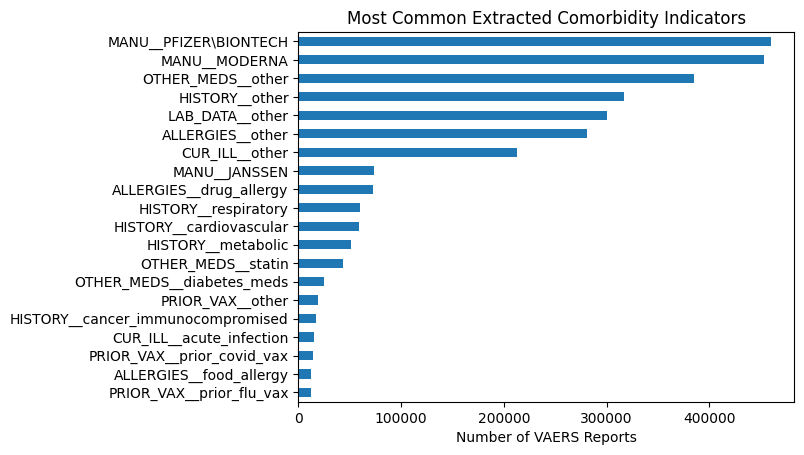

In [27]:
import matplotlib.pyplot as plt

summary.head(20)["count"].sort_values().plot(kind="barh")

plt.title("Most Common Extracted Comorbidity Indicators")
plt.xlabel("Number of VAERS Reports")
plt.show()

In [20]:
[c for c in df_clean.columns if "SYMPTOM" in c]

['SYMPTOM_TEXT']

In [23]:
import re
import pandas as pd

# -----------------------------
# Administrative / reporting-template terms to remove
# -----------------------------
admin_patterns = [
    r"\blot number\b",
    r"\bbatch number\b",
    r"\broute administration\b",
    r"\bunspecified route\b",
    r"\bdosage form\b",
    r"\bform\b",
    r"\bintramuscular\b",
    r"\bpatient received\b",
    r"\breported\b",
    r"\bcase\b",
    r"\bunknown date\b",
    r"\bdate patient\b",
    r"\breporter\b",
    r"\bfollowing information\b",
    r"\badmin\b",
    r"\bprophylactic vaccination\b",
    r"\bvaccine lot\b",
    r"\bsingle dose\b",
    r"\bnumber unknown\b",
    r"\bcontactable\b",
    r"\bdescribed\b",
    r"\bsubject experienced\b",
    r"\bsubject\b",
    r"\breceived covid\b",
    r"\bcovid vaccine\b",
    r"\bvaccine\b",
    r"\bmoderna\b",
    r"\bpfizer\b",
    r"\bpfizer-biontech\b",
    r"\bbiontech\b",
    r"\bjanssen\b",
    r"\bnovavax\b",
    r"\bmrna\b",
    r"\bbnt\b"
]

admin_regexes = [re.compile(p) for p in admin_patterns]

def remove_admin_terms(text):
    if pd.isna(text) or text == "":
        return ""
    text = str(text)
    for rgx in admin_regexes:
        text = rgx.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply to clustering text only
df_clean["SYMPTOM_TEXT_CLEAN_CLUSTER"] = df_clean["SYMPTOM_TEXT_CLEAN"].apply(remove_admin_terms)

In [ ]:
### CLustering prep

import os, re
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

OUTDIR = "/Users/ariellerothman/Desktop/Capstone/Outputs"
os.makedirs(OUTDIR, exist_ok=True)

TEXT_COL = "SYMPTOM_TEXT"

_url_re = re.compile(r"http\S+|www\S+|https\S+")
_email_re = re.compile(r"\S+@\S+")
_num_re = re.compile(r"\d+")
_keep_re = re.compile(r"[^a-z0-9\s\-]")
_ws = re.compile(r"\s+")

def clean_symptom_text(x: str) -> str:
    if pd.isna(x) or x == "":
        return ""
    x = str(x).strip().lower()
    x = _url_re.sub(" ", x)
    x = _email_re.sub(" ", x)
    x = _num_re.sub(" __NUM__ ", x)
    x = _keep_re.sub(" ", x)
    x = _ws.sub(" ", x).strip()
    return x

# Optional leakage scrub (supervised ONLY)
LEAKAGE_PATTERNS = [re.compile(p) for p in [
    r"\bhospitali[sz]ed\b", r"\bicu\b", r"\ber\b", r"\bemergency\b",
    r"\bdeath\b", r"\bdied\b", r"\blife[-\s]?threaten\w*\b",
    r"\bintubat\w*\b", r"\bventilat\w*\b"
]]

def scrub_leakage_terms(x: str) -> str:
    if not x:
        return ""
    for p in LEAKAGE_PATTERNS:
        x = p.sub(" ", x)
    return _ws.sub(" ", x).strip()

df_clean = df_clean.copy()
df_clean["SYMPTOM_TEXT_CLEAN"] = df_clean[TEXT_COL].apply(clean_symptom_text)
df_clean["SYMPTOM_TEXT_CLEAN_NOLEAK"] = df_clean["SYMPTOM_TEXT_CLEAN"].apply(scrub_leakage_terms)

# TF-IDF fit for clustering/EDA (fit once on full corpus)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=10,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True,
    norm="l2",
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]+\b|__NUM__"
)

X_tfidf = tfidf.fit_transform(df_clean["SYMPTOM_TEXT_CLEAN"])
sp.save_npz(os.path.join(OUTDIR, "symptom_text_tfidf.npz"), X_tfidf)

vocab = tfidf.get_feature_names_out()
pd.DataFrame({"term": vocab}).to_csv(os.path.join(OUTDIR, "tfidf_vocabulary.csv"), index=False)

# SVD for clustering
svd = TruncatedSVD(n_components=200, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)
X_lsa = Normalizer(copy=False).fit_transform(X_lsa)

np.save(os.path.join(OUTDIR, "symptom_text_lsa_200d.npy"), X_lsa)
np.save(os.path.join(OUTDIR, "svd_components_200d.npy"), svd.components_)
np.save(os.path.join(OUTDIR, "svd_explained_variance_ratio_200d.npy"), svd.explained_variance_ratio_)

print("Saved TF-IDF + LSA artifacts for clustering.")

Saved TF-IDF + LSA artifacts for clustering.


In [33]:
[c for c in df_clean.columns if "SYMPTOM" in c]

['SYMPTOM_TEXT',
 'SYMPTOM_TEXT_CLEAN',
 'SYMPTOM_TEXT_CLEAN_NOLEAK',
 'SYMPTOM_TEXT_CLEAN_CLUSTER']

X_lsa shape: (986096, 200)
k= 5 | silhouette=0.0517 | inertia=8.09e+05
k= 8 | silhouette=0.0677 | inertia=7.76e+05
k=10 | silhouette=0.0560 | inertia=7.68e+05
k=12 | silhouette=0.0409 | inertia=7.63e+05
k=15 | silhouette=0.0442 | inertia=7.47e+05


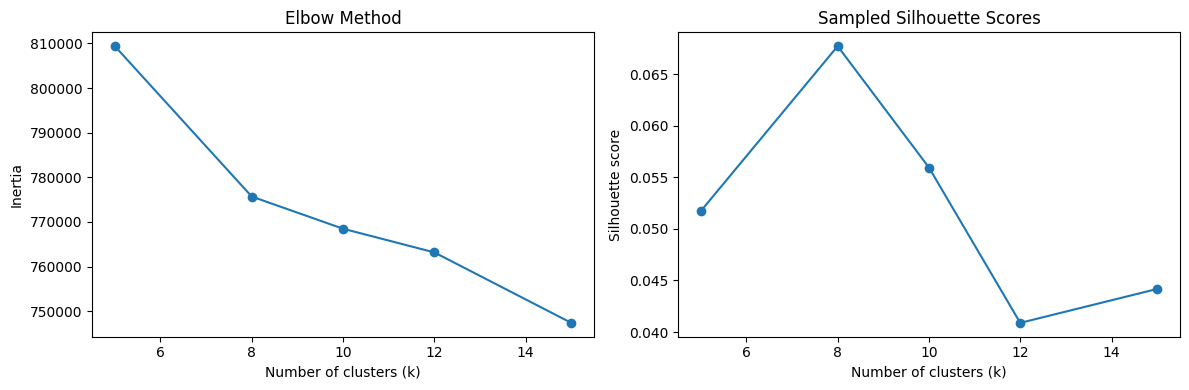

In [24]:
##Model selection for clustering plus shiloutte

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

OUTDIR = "/Users/ariellerothman/Desktop/Capstone/Outputs"

# -----------------------------
# Load reduced text representation
# -----------------------------
X_lsa = np.load(f"{OUTDIR}/symptom_text_lsa_200d.npy").astype(np.float32)

print("X_lsa shape:", X_lsa.shape)

# -----------------------------
# Sample for silhouette / stability diagnostics
# -----------------------------
rng = np.random.default_rng(42)

silhouette_sample_size = 20000
silhouette_idx = rng.choice(X_lsa.shape[0], size=silhouette_sample_size, replace=False)
X_sil = X_lsa[silhouette_idx]

k_values = [5, 8, 10, 12, 15]

elbow_results = []

for k in k_values:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000,
        n_init=3
    )
    
    labels_full = km.fit_predict(X_lsa)
    labels_sil = labels_full[silhouette_idx]
    
    sil = silhouette_score(X_sil, labels_sil)
    
    elbow_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": sil
    })
    
    print(f"k={k:2d} | silhouette={sil:.4f} | inertia={km.inertia_:.2e}")

elbow_df = pd.DataFrame(elbow_results)
elbow_df.to_csv(f"{OUTDIR}/cluster_selection_metrics.csv", index=False)

# -----------------------------
# Plot elbow + silhouette
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(elbow_df["k"], elbow_df["inertia"], marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(elbow_df["k"], elbow_df["silhouette"], marker="o")
ax[1].set_title("Sampled Silhouette Scores")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

In [25]:
### Stability across random seeds
from sklearn.metrics import adjusted_rand_score

# -----------------------------
# Stability analysis on subset
# -----------------------------
stability_sample_size = 50000
stability_idx = rng.choice(X_lsa.shape[0], size=stability_sample_size, replace=False)
X_stability = X_lsa[stability_idx]

# Set your chosen k here after reviewing elbow + silhouette
best_k = 10

seeds = [1, 7, 21, 42, 88]
labels_by_seed = {}

for seed in seeds:
    km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=seed,
        batch_size=10000,
        n_init=3
    )
    labels_by_seed[seed] = km.fit_predict(X_stability)

# Pairwise ARI between seeds
stability_results = []

for i, seed_a in enumerate(seeds):
    for seed_b in seeds[i+1:]:
        ari = adjusted_rand_score(labels_by_seed[seed_a], labels_by_seed[seed_b])
        stability_results.append({
            "seed_a": seed_a,
            "seed_b": seed_b,
            "ARI": ari
        })

stability_df = pd.DataFrame(stability_results)
print(stability_df)
print("\nMean ARI:", stability_df["ARI"].mean())

stability_df.to_csv(f"{OUTDIR}/cluster_stability_ari.csv", index=False)

   seed_a  seed_b       ARI
0       1       7  0.537080
1       1      21  0.376980
2       1      42  0.605001
3       1      88  0.518555
4       7      21  0.449776
5       7      42  0.603793
6       7      88  0.612484
7      21      42  0.377626
8      21      88  0.308709
9      42      88  0.549339

Mean ARI: 0.49393427269567897


In [26]:
##CHoose final model 
# -----------------------------
# Final model on full dataset
# -----------------------------
final_km = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=10000,
    n_init=5
)

df_clean = df_clean.copy()
df_clean["CLUSTER"] = final_km.fit_predict(X_lsa)

print(df_clean["CLUSTER"].value_counts().sort_index())

CLUSTER
0     12683
1     93549
2     58117
3     29324
4     30532
5     20816
6     51062
7     22061
8     84079
9    583873
Name: count, dtype: int64


In [27]:
##Interpret clusters using reconsturcted term weighrs
# -----------------------------
# Load vocabulary + SVD components
# -----------------------------
vocab_df = pd.read_csv(f"{OUTDIR}/tfidf_vocabulary.csv")
feature_names = vocab_df["term"].values

svd_components = np.load(f"{OUTDIR}/svd_components_200d.npy")

# final_km.cluster_centers_ shape = (k, 200)
# svd_components shape = (200, vocab_size)

# Reconstruct cluster centroids into original term space
reconstructed_centroids = final_km.cluster_centers_ @ svd_components

top_terms_per_cluster = {}

for cluster_id in range(best_k):
    centroid = reconstructed_centroids[cluster_id]
    top_idx = np.argsort(centroid)[::-1][:20]
    top_terms = feature_names[top_idx]
    top_terms_per_cluster[cluster_id] = top_terms
    
    print(f"\nCluster {cluster_id} top terms:")
    print(", ".join(top_terms))

# Save top terms
top_terms_rows = []
for cluster_id, terms in top_terms_per_cluster.items():
    for rank, term in enumerate(terms, start=1):
        top_terms_rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "term": term
        })

top_terms_df = pd.DataFrame(top_terms_rows)
top_terms_df.to_csv(f"{OUTDIR}/cluster_top_terms.csv", index=False)


Cluster 0 top terms:
acute, failure, respiratory, respiratory failure, pneumonia, hypoxemic, acute respiratory, hypoxemic respiratory, covid, hypoxia, chronic, acute hypoxemic, hospitalized, diarrhea, admitted, covid pneumonia, dizziness, hypoxic, remdesivir, home

Cluster 1 top terms:
mrna, moderna covid, mrna moderna, moderna, unknown, patient, covid vaccine, covid, received, vaccine, dosage, patient received, reported, dose mrna, case, dosage form, vaccine intramuscular, form, intramuscular, experienced

Cluster 2 top terms:
unspecified, patient, lot, covid, number, bnt, dose, unspecified route, route administration, reported, pfizer-biontech, pfizer-biontech covid, single, bnt pfizer-biontech, lot number, administration, vaccine, date, received, contactable

Cluster 3 top terms:
unknown, mrna moderna, moderna covid, mrna, moderna, vaccine unknown, covid vaccine, covid, reported, patient, unknown date, date patient, dosage, case, vaccine, received, dose mrna, dosage form, form, dat

In [28]:
#compare clusters aross severity groups
# -----------------------------
# Cluster vs SERIOUS
# -----------------------------
cluster_serious = pd.crosstab(
    df_clean["CLUSTER"],
    df_clean["SERIOUS"],
    normalize="index"
)

print(cluster_serious)
cluster_serious.to_csv(f"{OUTDIR}/cluster_vs_serious.csv")

SERIOUS         0         1
CLUSTER                    
0        0.039344  0.960656
1        0.935617  0.064383
2        0.862278  0.137722
3        0.973162  0.026838
4        0.555090  0.444910
5        0.863422  0.136578
6        0.905820  0.094180
7        0.880241  0.119759
8        0.953044  0.046956
9        0.758643  0.241357


In [29]:
#Compare clusters across demographics
# -----------------------------
# Cluster vs SEX
# -----------------------------
cluster_sex = pd.crosstab(
    df_clean["CLUSTER"],
    df_clean["SEX"],
    normalize="index"
)

print(cluster_sex)
cluster_sex.to_csv(f"{OUTDIR}/cluster_vs_sex.csv")

# -----------------------------
# Cluster vs age summary
# -----------------------------
cluster_age = df_clean.groupby("CLUSTER")["AGE_YRS"].describe()
print(cluster_age)
cluster_age.to_csv(f"{OUTDIR}/cluster_age_summary.csv")

SEX             F         M         U
CLUSTER                              
0        0.465426  0.530158  0.004415
1        0.635495  0.285167  0.079338
2        0.653136  0.266093  0.080771
3        0.418253  0.228659  0.353088
4        0.670204  0.324948  0.004848
5        0.457705  0.294098  0.248198
6        0.602142  0.297111  0.100747
7        0.740538  0.251983  0.007479
8        0.832301  0.162181  0.005519
9        0.629874  0.356868  0.013258
            count       mean        std   min   25%   50%   75%    max
CLUSTER                                                               
0         12636.0  68.959124  16.239673  0.58  61.0  72.0  80.0  106.0
1         76032.0  58.225159  18.685503  0.08  46.0  62.0  72.0  109.0
2         35221.0  53.396785  18.456341  0.08  39.0  55.0  68.0  102.0
3          8493.0  57.742308  20.058291  0.25  43.0  62.0  73.0  104.0
4         30298.0  47.494092  17.526324  0.08  34.0  47.0  61.0  103.0
5          7725.0  50.314144  17.219190  0.17  

In [30]:
manufacturer_cols = [c for c in df_clean.columns if c.startswith("MANU__")]

cluster_manu = df_clean.groupby("CLUSTER")[manufacturer_cols].mean()
print(cluster_manu)
cluster_manu.to_csv(f"{OUTDIR}/cluster_vs_manufacturer.csv")

         MANU__JANSSEN_x  MANU__MODERNA_x  MANU__NOVAVAX_x  \
CLUSTER                                                      
0               0.075850         0.373807         0.000473   
1               0.002405         0.991106         0.000107   
2               0.000206         0.001617         0.000430   
3               0.001671         0.997340         0.000000   
4               0.087089         0.411699         0.001507   
5               0.984531         0.014316         0.000000   
6               0.001058         0.006463         0.000137   
7               0.000091         0.000861         0.000045   
8               0.036359         0.712889         0.000844   
9               0.078786         0.433281         0.000978   

         MANU__PFIZER\BIONTECH_x  MANU__UNKNOWN MANUFACTURER_x  \
CLUSTER                                                          
0                       0.554758                      0.002129   
1                       0.006788                      0.0

In [31]:
comorb_cols = [c for c in df_clean.columns if "__" in c and not c.startswith("MANU__")]

print("Comorbidity columns:", len(comorb_cols))

cluster_comorb = df_clean.groupby("CLUSTER")[comorb_cols].mean()

cluster_comorb.to_csv(f"{OUTDIR}/cluster_vs_comorbidities.csv")

print(cluster_comorb.iloc[:, :10])

Comorbidity columns: 48
         HISTORY__cardiovascular  HISTORY__respiratory  HISTORY__metabolic  \
CLUSTER                                                                      
0                       0.276591              0.144840            0.212805   
1                       0.007087              0.004789            0.004254   
2                       0.039661              0.045099            0.040057   
3                       0.001057              0.000784            0.000477   
4                       0.085255              0.094950            0.065210   
5                       0.009464              0.006822            0.007398   
6                       0.045102              0.059966            0.047942   
7                       0.055936              0.083496            0.056480   
8                       0.063214              0.080793            0.067222   
9                       0.077287              0.068883            0.067105   

         HISTORY__kidney  HISTORY__clot

In [32]:
cluster_summary = df_clean.groupby("CLUSTER").agg({
    "SERIOUS": "mean",
    "AGE_YRS": "mean",
    "VAERS_ID": "count"
}).rename(columns={"VAERS_ID": "N", "SERIOUS": "SERIOUS_RATE", "AGE_YRS": "MEAN_AGE"})

print(cluster_summary)
cluster_summary.to_csv(f"{OUTDIR}/cluster_summary.csv")

         SERIOUS_RATE   MEAN_AGE       N
CLUSTER                                 
0            0.960656  68.959124   12683
1            0.064383  58.225159   93549
2            0.137722  53.396785   58117
3            0.026838  57.742308   29324
4            0.444910  47.494092   30532
5            0.136578  50.314144   20816
6            0.094180  52.929288   51062
7            0.119759  45.909941   22061
8            0.046956  49.780525   84079
9            0.241357  48.351920  583873


In [ ]:
df_clean.to_csv(f"{OUTDIR}/vaers_dataset_with_features.csv", index=False)

In [ ]:
## supervised 
import os, re
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

OUTDIR = "/Users/ariellerothman/Desktop/Capstone/Outputs"
os.makedirs(OUTDIR, exist_ok=True)

TEXT_COL = "SYMPTOM_TEXT"

_url_re = re.compile(r"http\S+|www\S+|https\S+")
_email_re = re.compile(r"\S+@\S+")
_num_re = re.compile(r"\d+")
_keep_re = re.compile(r"[^a-z0-9\s\-]")
_ws = re.compile(r"\s+")

def clean_symptom_text(x: str) -> str:
    if pd.isna(x) or x == "":
        return ""
    x = str(x).strip().lower()
    x = _url_re.sub(" ", x)
    x = _email_re.sub(" ", x)
    x = _num_re.sub(" __NUM__ ", x)
    x = _keep_re.sub(" ", x)
    x = _ws.sub(" ", x).strip()
    return x

# Optional leakage scrub (supervised ONLY)
LEAKAGE_PATTERNS = [re.compile(p) for p in [
    r"\bhospitali[sz]ed\b", r"\bicu\b", r"\ber\b", r"\bemergency\b",
    r"\bdeath\b", r"\bdied\b", r"\blife[-\s]?threaten\w*\b",
    r"\bintubat\w*\b", r"\bventilat\w*\b"
]]

def scrub_leakage_terms(x: str) -> str:
    if not x:
        return ""
    for p in LEAKAGE_PATTERNS:
        x = p.sub(" ", x)
    return _ws.sub(" ", x).strip()

df_clean = df_clean.copy()
df_clean["SYMPTOM_TEXT_CLEAN"] = df_clean[TEXT_COL].apply(clean_symptom_text)
df_clean["SYMPTOM_TEXT_CLEAN_NOLEAK"] = df_clean["SYMPTOM_TEXT_CLEAN"].apply(scrub_leakage_terms)

# TF-IDF fit for clustering/EDA (fit once on full corpus)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=10,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True,
    norm="l2",
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]+\b|__NUM__"
)

X_tfidf = tfidf.fit_transform(df_clean["SYMPTOM_TEXT_CLEAN"])
sp.save_npz(os.path.join(OUTDIR, "symptom_text_tfidf.npz"), X_tfidf)

vocab = tfidf.get_feature_names_out()
pd.DataFrame({"term": vocab}).to_csv(os.path.join(OUTDIR, "tfidf_vocabulary.csv"), index=False)

# SVD for clustering
svd = TruncatedSVD(n_components=200, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)
X_lsa = Normalizer(copy=False).fit_transform(X_lsa)

np.save(os.path.join(OUTDIR, "symptom_text_lsa_200d.npy"), X_lsa)
np.save(os.path.join(OUTDIR, "svd_components_200d.npy"), svd.components_)
np.save(os.path.join(OUTDIR, "svd_explained_variance_ratio_200d.npy"), svd.explained_variance_ratio_)

print("Saved TF-IDF + LSA artifacts for clustering.")